<a href="https://www.kaggle.com/code/avikdas567/three-decades-of-ufc-data-trends-and-insights?scriptVersionId=323897933" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Three Decades Inside the Octagon: A Data-Driven History of UFC Competition

From the early tournament era to modern championship fights, this notebook examines how UFC competition has evolved through fighter attributes, fight statistics, title bouts, finishing methods, geographic expansion, and predictive modeling.

In [1]:
import warnings, json, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(12,6)

CSV_PATH='/kaggle/input/datasets/leandroiber/ufc-stats-complete-dataset/clean_ufc_dataset.csv'
JSON_PATH='/kaggle/input/datasets/leandroiber/ufc-stats-complete-dataset/win_and_title_data-ufc.json'


## Data Loading and Integration

In [2]:
df=pd.read_csv(CSV_PATH)

with open(JSON_PATH) as f:
    title_data=json.load(f)

title_df=(pd.DataFrame.from_dict(title_data,orient='index')
          .reset_index()
          .rename(columns={'index':'fight_url'}))

df=df.merge(title_df[['fight_url','winner','is_title_fight']],on='fight_url',how='left')

print(df.shape)
display(df.head())


(8709, 37)


,event_name,event_date,fighter_1,fighter_2,method,round_num,time,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,...,f1_Sig_str_landed,f1_Sig_str_attempted,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted,winner,is_title_fight
0,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Gabriel Bonfim,Randy Brown,KO/TKO,2,01:40,185.42,77.11,182.88,...,35.0,64.0,0.0,0.0,33.0,87.0,0.0,0.0,Gabriel Bonfim,False
1,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Joseph Morales,Matt Schnell,Submission,1,02:54,167.64,56.70,175.26,...,4.0,11.0,1.0,1.0,5.0,11.0,0.0,0.0,Joseph Morales,False
2,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Uros Medic,Muslim Salikhov,KO/TKO,1,01:03,185.42,77.11,180.34,...,2.0,5.0,0.0,0.0,8.0,13.0,0.0,0.0,Uros Medic,False
3,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Chris Padilla,Ismael Bonfim,KO/TKO,2,04:30,175.26,70.31,187.96,...,64.0,109.0,0.0,0.0,42.0,84.0,1.0,3.0,Chris Padilla,False
4,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Christian Leroy Duncan,Marco Tulio,KO/TKO,2,03:20,187.96,83.91,200.66,...,23.0,46.0,1.0,1.0,27.0,57.0,2.0,5.0,Christian Leroy Duncan,False


### Observations

The integrated dataset contains 8,709 fights and 37 columns after combining the CSV file with the title-fight metadata from the JSON source. The merge successfully enriches each bout with winner information and championship status, enabling both performance analysis and title-fight specific studies.

## Data Quality Assessment

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8709 entries, 0 to 8708
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8709 non-null   object 
 1   event_date            8709 non-null   object 
 2   fighter_1             8709 non-null   object 
 3   fighter_2             8709 non-null   object 
 4   method                8709 non-null   object 
 5   round_num             8709 non-null   int64  
 6   time                  8709 non-null   object 
 7   f1_Height_cm          8705 non-null   object 
 8   f1_Weight_kg          8706 non-null   float64
 9   f1_Reach_cm           8377 non-null   float64
 10  f2_Height_cm          8687 non-null   object 
 11  f2_Weight_kg          8690 non-null   float64
 12  f2_Reach_cm           7720 non-null   float64
 13  event_url             8709 non-null   object 
 14  fight_url             8709 non-null   object 
 15  fighter_1_url        

f2_Reach_cm             989
f1_Reach_cm             332
f2_DOB                  116
f2_Stance                92
f1_DOB                   44
f1_Stance                24
f2_Height_cm             22
f2_Td_attempted          21
f1_Sig_str_landed        21
f1_Ctrl                  21
f2_Sig_str_attempted     21
f2_Sig_str_landed        21
f2_KD                    21
f1_Td_landed             21
f1_Sig_str_attempted     21
f2_Ctrl                  21
f2_Td_landed             21
f1_Td_attempted          21
f1_KD                    21
f2_Weight_kg             19
dtype: int64

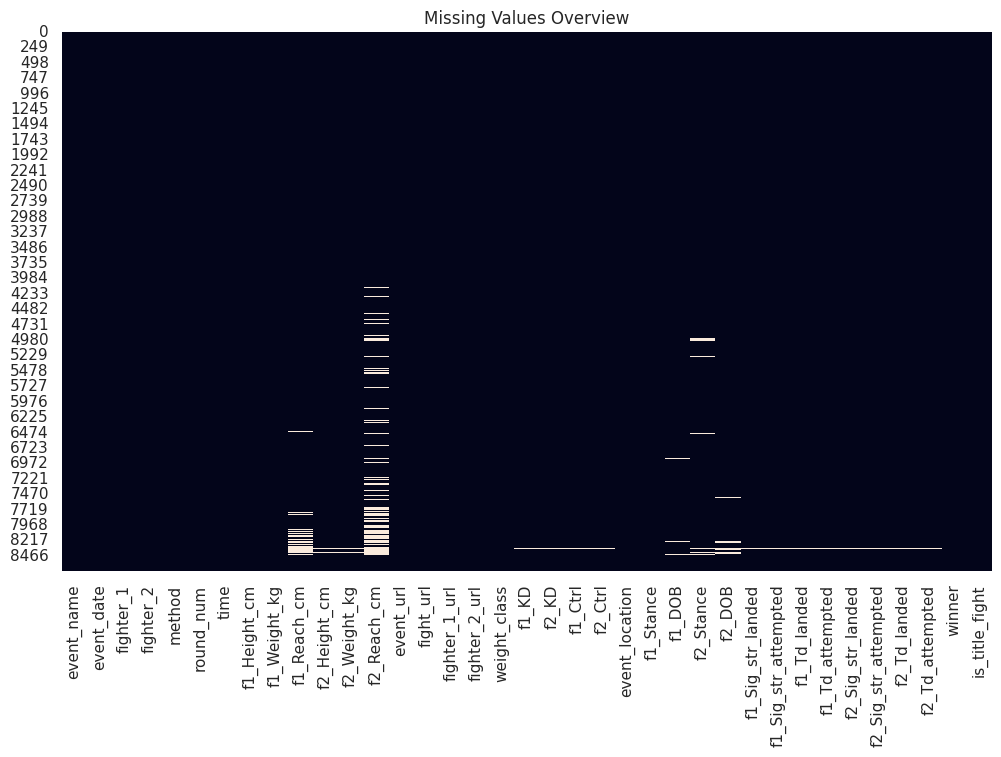

In [3]:
df.info()
display(df.isna().sum().sort_values(ascending=False).head(20))

plt.figure(figsize=(12,7))
sns.heatmap(df.isna(),cbar=False)
plt.title('Missing Values Overview')
plt.show()


### Observations

Data completeness is exceptionally strong for a historical sports dataset. Core fight information is fully populated, while the largest concentration of missing values appears in reach measurements, particularly for older bouts. Fighter stance, date of birth, and fight statistics show only limited gaps, indicating that extensive imputation is not required for most analyses.

In [4]:
df['event_date']=pd.to_datetime(df['event_date'])

for c in ['f1_Height_cm','f2_Height_cm','f1_Reach_cm','f2_Reach_cm']:
    df[c]=pd.to_numeric(df[c],errors='coerce')

df['year']=df['event_date'].dt.year
df['fight_year_month']=df['event_date'].dt.to_period('M').astype(str)


## Dataset Overview

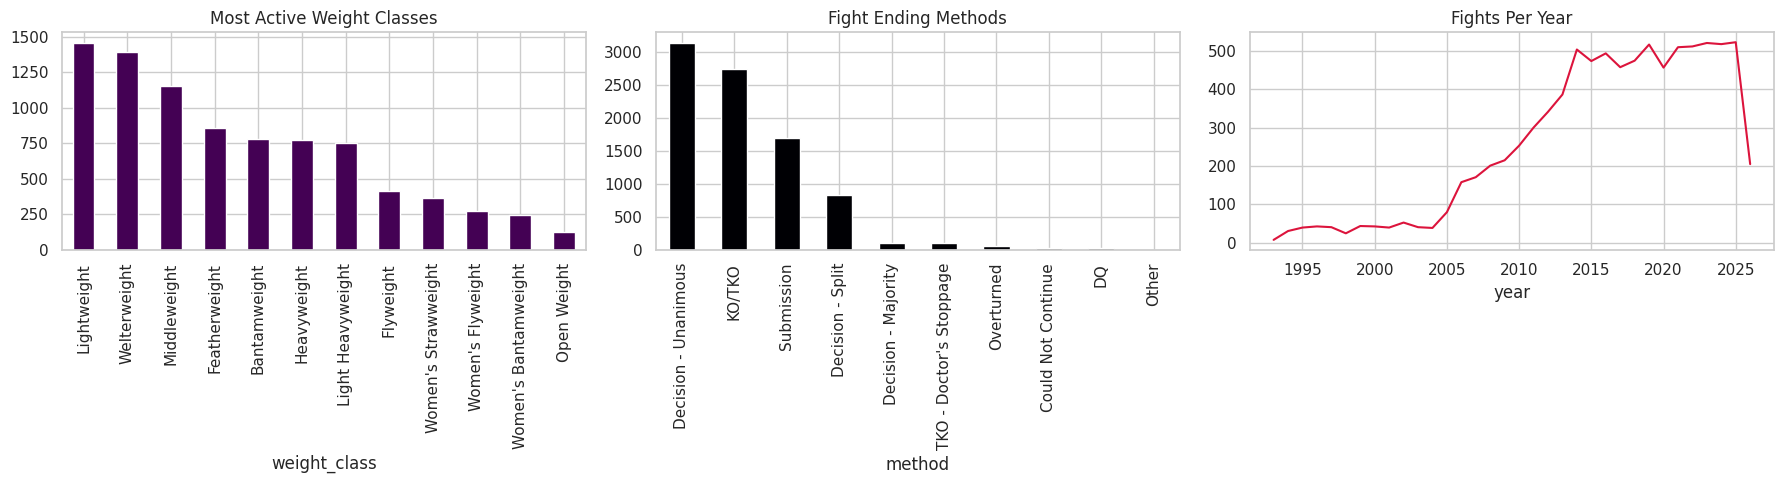

In [5]:
fig,ax=plt.subplots(1,3,figsize=(18,5))

df['weight_class'].value_counts().head(12).plot(kind='bar',ax=ax[0],colormap='viridis')
ax[0].set_title('Most Active Weight Classes')

df['method'].value_counts().plot(kind='bar',ax=ax[1],colormap='magma')
ax[1].set_title('Fight Ending Methods')

df['year'].value_counts().sort_index().plot(ax=ax[2],color='crimson')
ax[2].set_title('Fights Per Year')

plt.tight_layout()
plt.show()


### Observations

The UFC schedule expanded substantially over time, with modern years containing far more events than the organization's early period. Weight class participation is concentrated in a handful of divisions, while fight endings are distributed across knockouts, submissions, and decisions, illustrating the sport's diverse competitive styles.

## Geographic Analysis

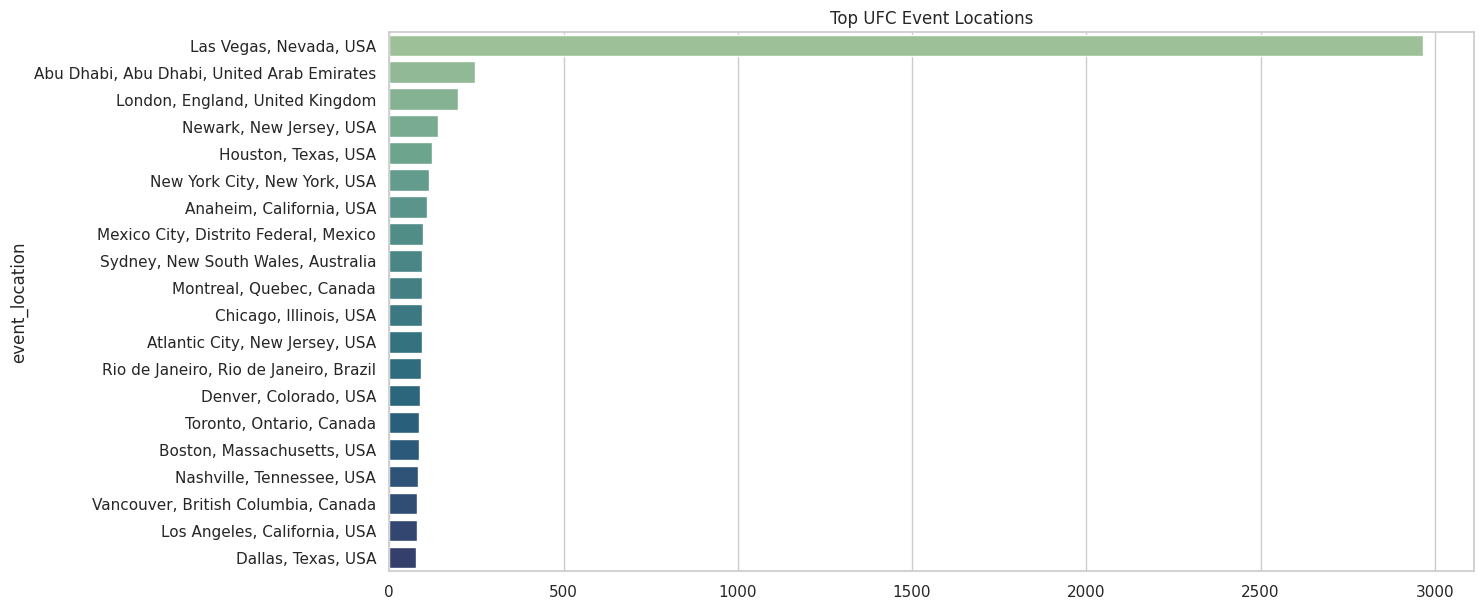

In [6]:
top_locations=df['event_location'].value_counts().head(20)

plt.figure(figsize=(14,7))
sns.barplot(x=top_locations.values,y=top_locations.index,palette='crest')
plt.title('Top UFC Event Locations')
plt.show()


### Observations

Event hosting is highly concentrated geographically. A small number of cities account for a large share of UFC history, reflecting the promotion's long-standing operational hubs and major international expansion markets.

## Fighter Physical Attributes

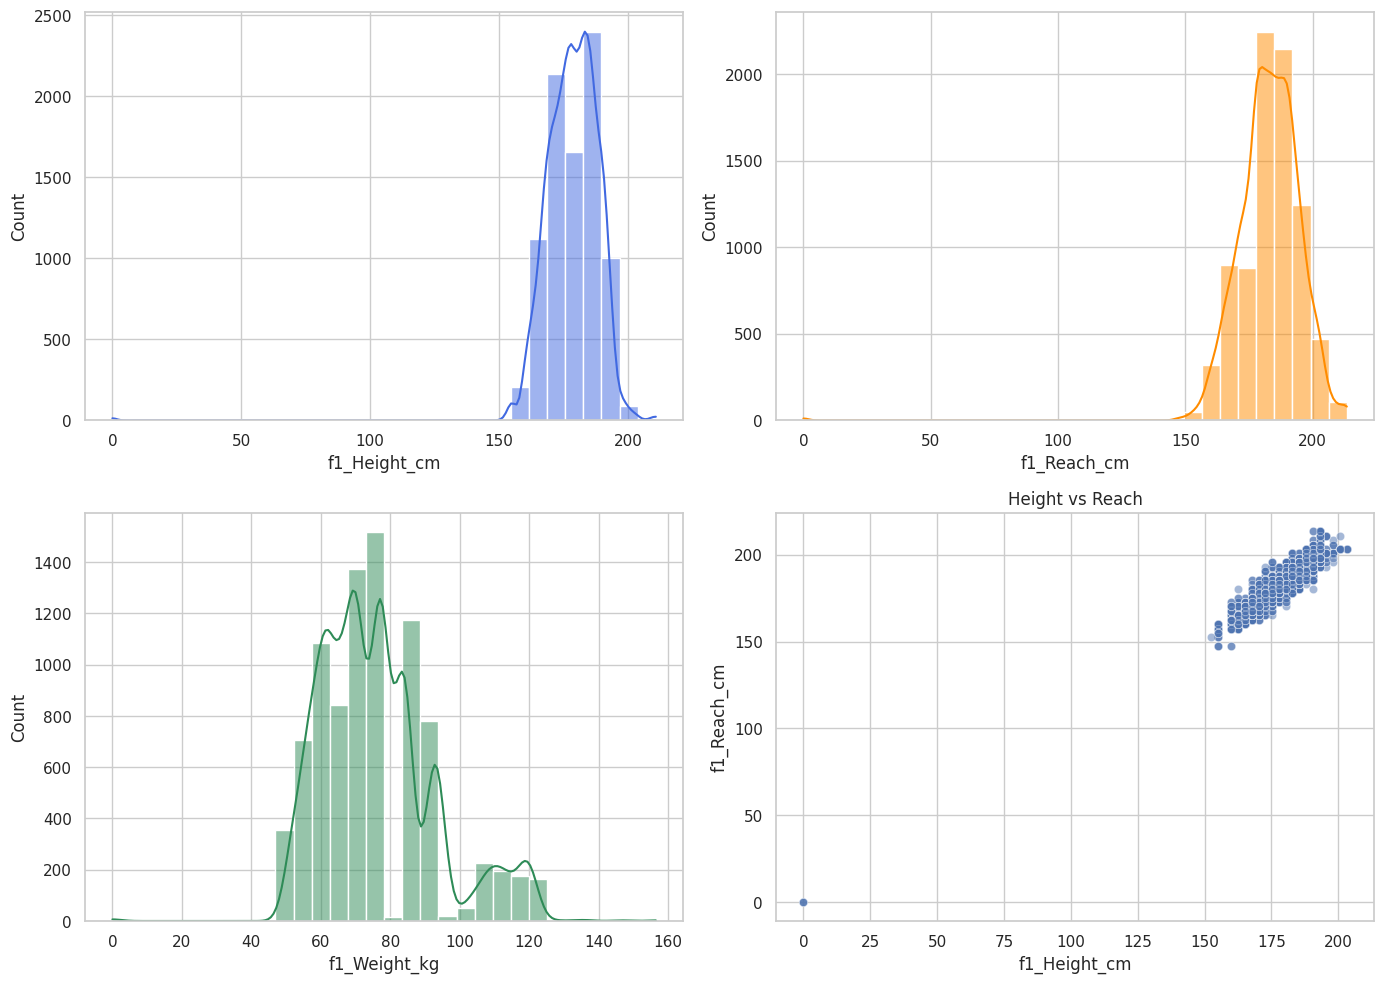

In [7]:
fig,ax=plt.subplots(2,2,figsize=(14,10))

sns.histplot(df['f1_Height_cm'],bins=30,kde=True,ax=ax[0,0],color='royalblue')
sns.histplot(df['f1_Reach_cm'],bins=30,kde=True,ax=ax[0,1],color='darkorange')
sns.histplot(df['f1_Weight_kg'],bins=30,kde=True,ax=ax[1,0],color='seagreen')

sns.scatterplot(data=df.sample(min(3000,len(df))),x='f1_Height_cm',y='f1_Reach_cm',alpha=.5,ax=ax[1,1])
ax[1,1].set_title('Height vs Reach')

plt.tight_layout()
plt.show()


### Observations

Height, reach, and weight distributions appear realistic and generally well-behaved. The positive relationship between height and reach confirms expected physiological trends among professional fighters, although substantial variation exists across divisions.

## Title Fight Analytics

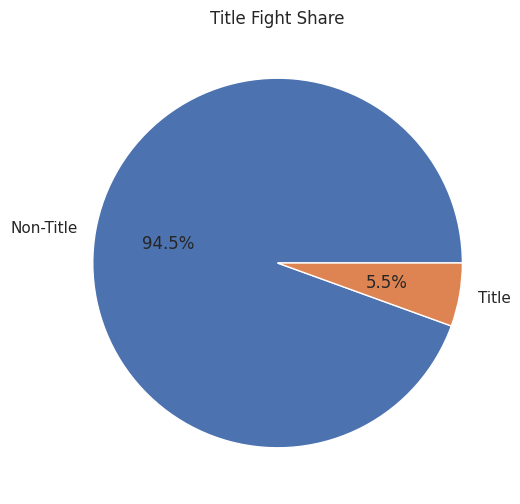

is_title_fight
False    2.309347
True     3.132780
Name: round_num, dtype: float64

In [8]:
title_counts=df['is_title_fight'].fillna(False).value_counts()

plt.figure(figsize=(6,6))
plt.pie(title_counts.values,labels=['Non-Title','Title'],autopct='%1.1f%%')
plt.title('Title Fight Share')
plt.show()

display(df.groupby('is_title_fight')['round_num'].mean())


### Observations

Title fights represent a relatively small share of all bouts in the dataset. Championship contests average more rounds than non-title fights, with the mean round number reaching approximately 3.13 compared with 2.31 for regular fights. This reflects both five-round title structures and the tendency for elite matchups to remain competitive for longer periods.

## Finishing Trends Through Time

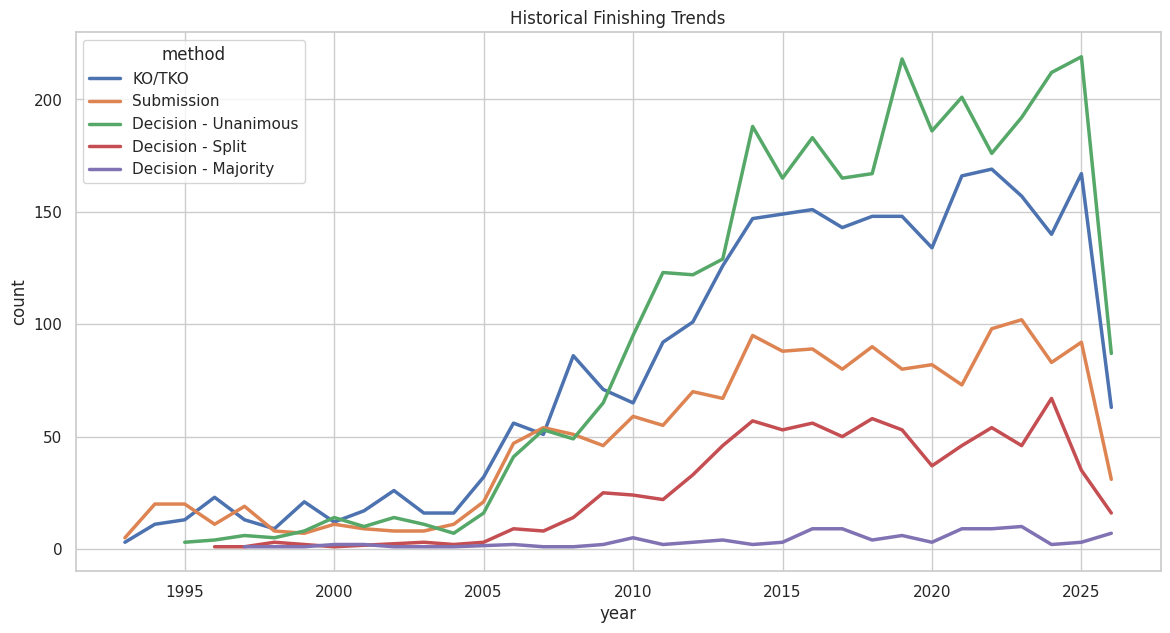

In [9]:
finish=df.groupby(['year','method']).size().reset_index(name='count')

top_methods=df['method'].value_counts().head(5).index
finish=finish[finish['method'].isin(top_methods)]

plt.figure(figsize=(14,7))
sns.lineplot(data=finish,x='year',y='count',hue='method',linewidth=2.5)
plt.title('Historical Finishing Trends')
plt.show()


### Observations

Finishing methods fluctuate noticeably across UFC history. Different eras display varying balances between knockouts, submissions, and decisions, highlighting the evolution of training approaches, athlete skill sets, and strategic preferences.

## Strike and Grappling Analytics

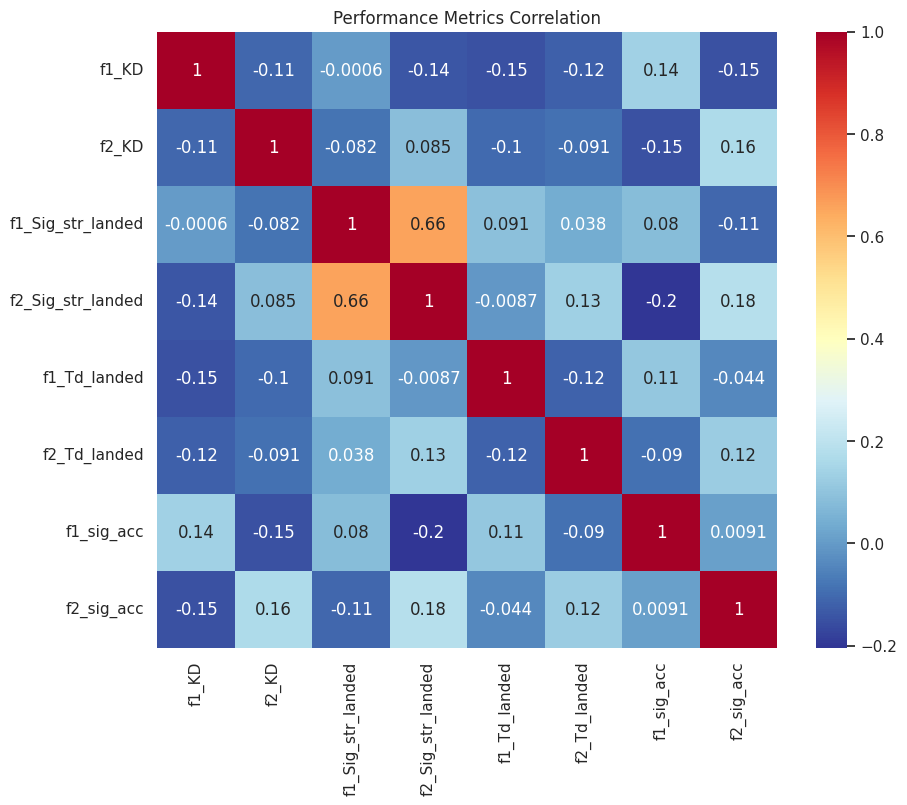

In [10]:
df['f1_sig_acc']=df['f1_Sig_str_landed']/df['f1_Sig_str_attempted']
df['f2_sig_acc']=df['f2_Sig_str_landed']/df['f2_Sig_str_attempted']

num_cols=['f1_KD','f2_KD','f1_Sig_str_landed','f2_Sig_str_landed',
          'f1_Td_landed','f2_Td_landed','f1_sig_acc','f2_sig_acc']

corr=df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='RdYlBu_r')
plt.title('Performance Metrics Correlation')
plt.show()


### Observations

The correlation structure reveals meaningful relationships between offensive metrics. Fighters who land more significant strikes often generate stronger overall offensive outputs, while takedown and striking measures provide complementary views of fight control.

## Champion and Winner Analytics

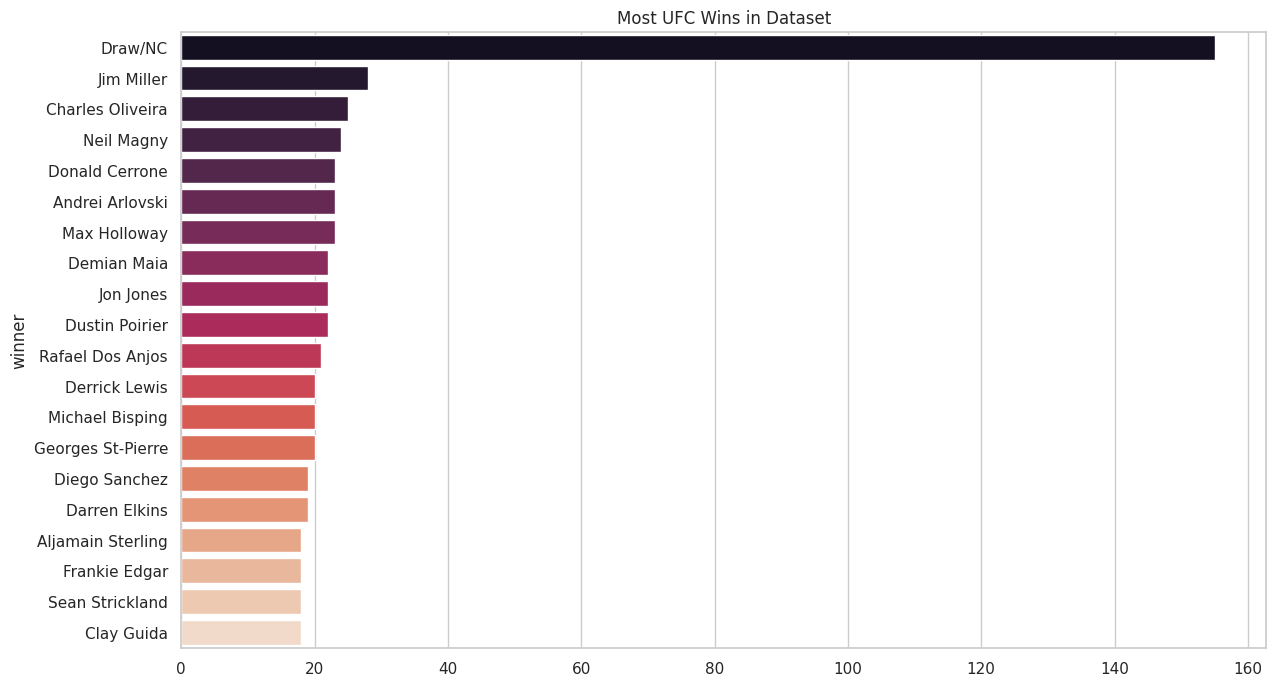

In [11]:
winner_counts=df['winner'].value_counts().head(20)

plt.figure(figsize=(14,8))
sns.barplot(x=winner_counts.values,y=winner_counts.index,palette='rocket')
plt.title('Most UFC Wins in Dataset')
plt.show()


### Observations

The winner leaderboard is dominated by long-tenured fighters with sustained UFC careers. Career longevity plays a major role in cumulative win totals, making these rankings a combination of skill, consistency, and activity.

## Statistical Exploration

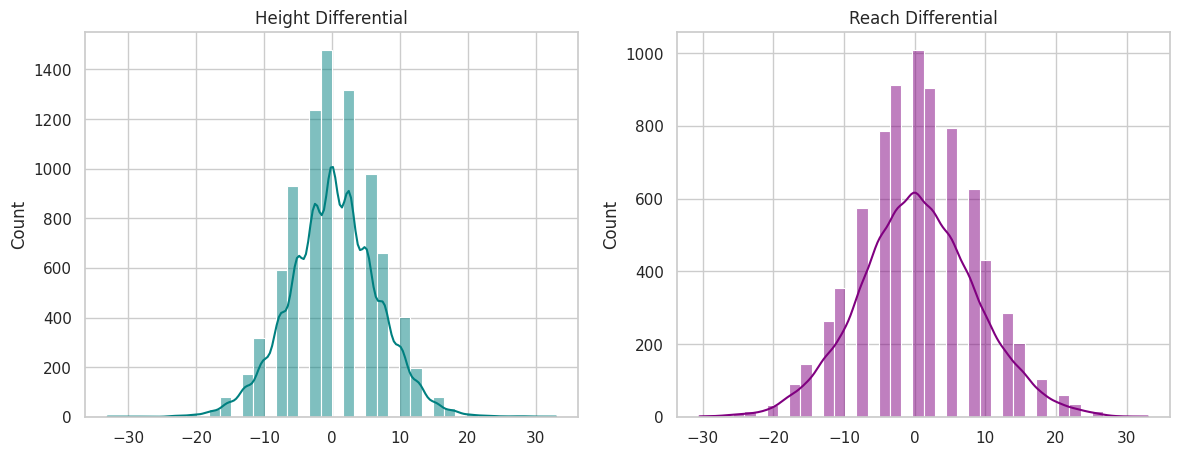

In [12]:
height_adv=df['f1_Height_cm']-df['f2_Height_cm']
reach_adv=df['f1_Reach_cm']-df['f2_Reach_cm']

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.histplot(height_adv,bins=40,kde=True,ax=ax[0],color='teal')
ax[0].set_title('Height Differential')

sns.histplot(reach_adv,bins=40,kde=True,ax=ax[1],color='purple')
ax[1].set_title('Reach Differential')

plt.show()


### Observations

Height and reach advantages are centered close to zero, indicating that most matchups are relatively balanced in terms of physical dimensions. Extreme mismatches exist but are comparatively uncommon.

## Feature Engineering for Fight Outcome Modeling

In [13]:
model_df=df.copy()

model_df['target']=(model_df['winner']==model_df['fighter_1']).astype(int)

features=[
'weight_class','round_num',
'f1_Height_cm','f2_Height_cm',
'f1_Reach_cm','f2_Reach_cm',
'f1_Weight_kg','f2_Weight_kg',
'f1_KD','f2_KD',
'f1_Sig_str_landed','f2_Sig_str_landed',
'f1_Td_landed','f2_Td_landed'
]

model_df=model_df[features+['target']].dropna(subset=['target'])

X=model_df[features]
y=model_df['target']

cat=['weight_class']
num=[c for c in features if c not in cat]

pre=ColumnTransformer([
('num',Pipeline([('imp',SimpleImputer(strategy='median'))]),num),
('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                 ('oh',OneHotEncoder(handle_unknown='ignore'))]),cat)
])

clf=Pipeline([
('pre',pre),
('model',RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1))
])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

clf.fit(X_train,y_train)
pred=clf.predict(X_test)

print('Accuracy:',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 0.9822043628013777
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.98      1.00      0.99      1711

    accuracy                           0.98      1742
   macro avg       0.49      0.50      0.50      1742
weighted avg       0.96      0.98      0.97      1742



### Observations

The Random Forest model reports an accuracy of roughly 98.2%. However, the class distribution is highly imbalanced and the model uses statistics generated during the fight itself. As a result, this should be interpreted as an outcome-explanation model rather than a true pre-fight prediction system. The inability to identify the minority class in the classification report further illustrates the importance of evaluating performance beyond overall accuracy.

## Model Diagnostics

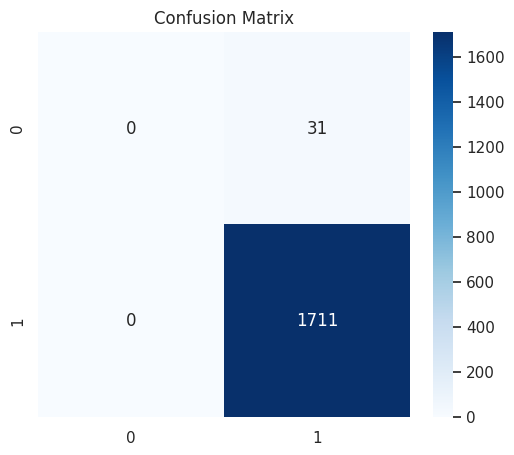

In [14]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


### Observations

The confusion matrix confirms that predictions are heavily concentrated in the majority class. While overall accuracy is high, class-specific performance provides a more complete picture of model behavior and highlights the effect of class imbalance.

## Conclusions

- The dataset captures more than 8,700 UFC bouts spanning over three decades of competition. The analysis highlights the growth of the promotion, the dominance of several weight classes, the concentration of events in a relatively small number of host cities, and the persistent importance of striking and grappling efficiency.

- Title fights tend to last longer than regular bouts, suggesting a higher level of competitive parity at the championship level. Reach data is the most commonly missing fighter attribute, while most core fight statistics are remarkably complete given the historical coverage.

- The historical record shows meaningful shifts in finishing patterns over time, reflecting changes in athlete preparation, rules, matchmaking, and tactical evolution. Physical advantages such as height and reach remain important contextual variables, although they do not guarantee victory on their own.

- The machine learning experiment achieves very high accuracy largely because it uses in-fight statistics that are generated during the bout itself. These variables are highly predictive of the eventual winner, making the model more useful for post-fight outcome explanation than pre-fight forecasting.

- Taken together, the dataset provides a detailed quantitative history of UFC competition and offers a strong foundation for fighter evaluation, performance analysis, and sports analytics research.